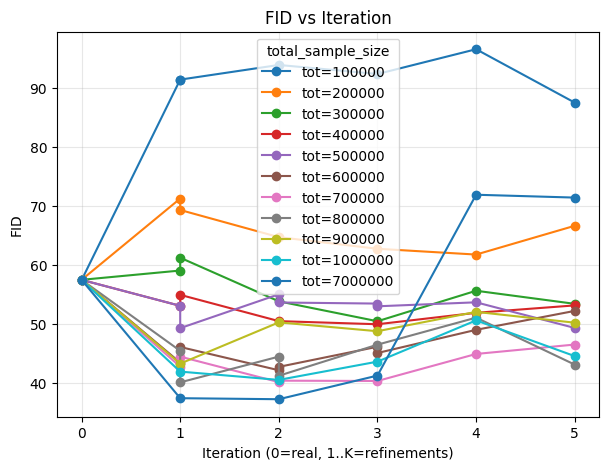

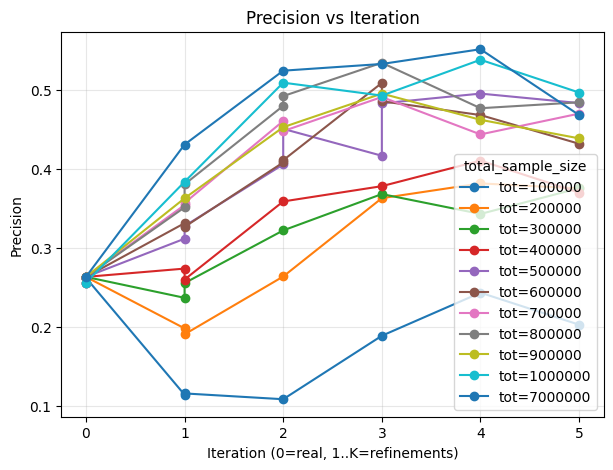

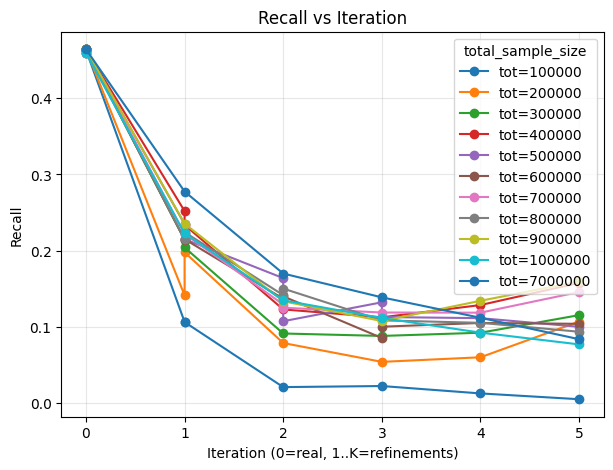

In [ ]:
from pathlib import Path
import re, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("data_filter/Verified-Synthetic-Data/MNIST")

TOT_LIST = [100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000, 7000000]
DIRS = [ROOT / f"diverse_up0.005_low0.005_keep0.5_tot{t}" for t in TOT_LIST]
CSV_REL = "metrics/metrics.csv"

def tag_to_iter(tag: str):
    if isinstance(tag, str) and tag.startswith("model_00_real"):
        return 0
    m = re.search(r"model_(\d+)", str(tag))
    return int(m.group(1)) if m else None

rows = []
for d in DIRS:
    csv_path = d / CSV_REL
    if not csv_path.is_file():
        print(f"[SKIP] {csv_path} not found")
        continue
    df = pd.read_csv(csv_path)
    if "tag" in df.columns:
        df["iteration"] = df["tag"].apply(tag_to_iter)
    else:
        df = df.reset_index().rename(columns={"index":"iteration"})
    df = df.dropna(subset=["iteration"])
    df["iteration"] = df["iteration"].astype(int)
    m = re.search(r"_tot(\d+)", d.name)
    df["total_attempts"] = int(m.group(1)) if m else None
    rows.append(df[["iteration","fid","precision","recall","total_attempts"]])

all_df = pd.concat(rows, ignore_index=True)

def plot_metric(metric, ylabel):
    plt.figure(figsize=(7,5))
    for tot, g in all_df.groupby("total_attempts"):
        g = g.sort_values("iteration")
        plt.plot(g["iteration"], g[metric], marker="o", label=f"tot={tot}")
    plt.xlabel("Iteration (0=real, 1..K=refinements)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Iteration")
    plt.legend(title="total_sample_size")
    plt.grid(alpha=0.3)
    plt.show()

plot_metric("fid", "FID")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")


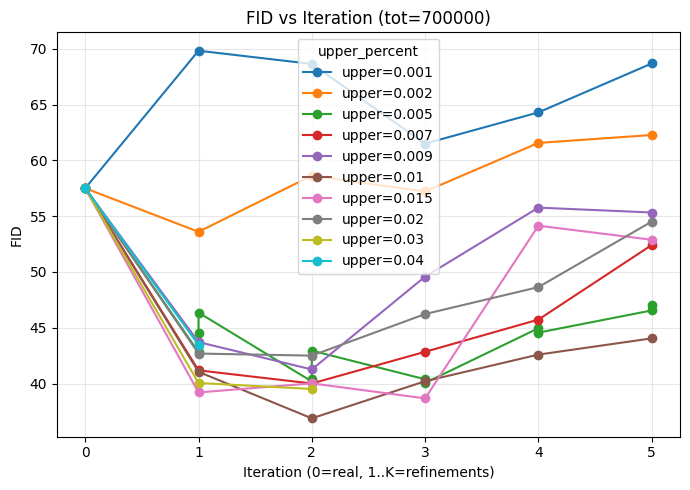

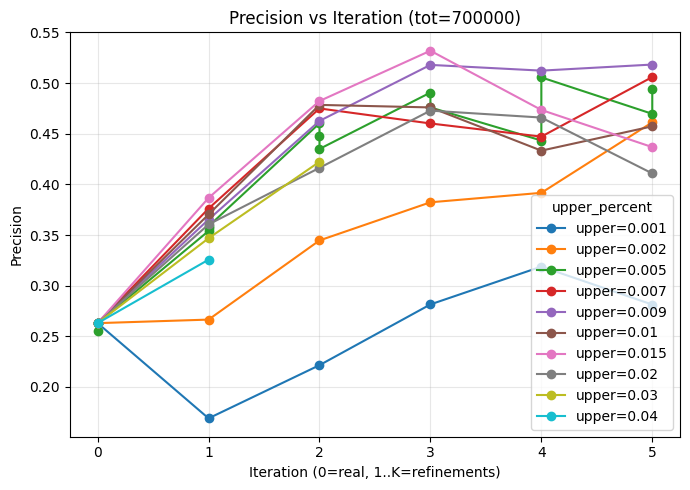

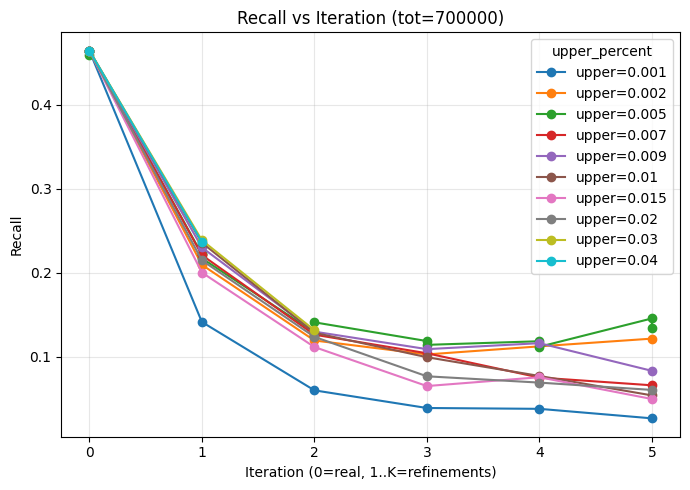

In [2]:
# Collect metrics for upper=lower (tot=700000) and plot FID / Precision / Recall vs iteration
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Find MNIST root robustly, even if you're inside .../diverse_.../metrics ---
cwd = Path.cwd().resolve()
MNIST_ROOT = None
for p in [cwd] + list(cwd.parents):
    if p.name == "MNIST":
        MNIST_ROOT = p
        break
if MNIST_ROOT is None:
    # Fallback to absolute path if needed; adjust to your environment
    MNIST_ROOT = Path.home() / "data_filter/Verified-Synthetic-Data/MNIST"

# --- Config (upper=lower list; tot fixed) ---
P_LIST = [0.001, 0.002, 0.005, 0.007, 0.009, 0.01, 0.015, 0.02, 0.03, 0.04]
TOT = 700000
CSV_REL = "metrics/metrics.csv"
EPS = 1e-12

def tag_to_iter(tag: str):
    if isinstance(tag, str) and tag.startswith("model_00_real"):
        return 0
    m = re.search(r"model_(\d+)", str(tag))
    return int(m.group(1)) if m else None

rows = []
for p in P_LIST:
    d = MNIST_ROOT / f"diverse_up{p:g}_low{p:g}_keep0.5_tot{TOT}"
    csv_path = d / CSV_REL
    if not csv_path.is_file():
        print(f"[SKIP] {csv_path} not found")
        continue
    df = pd.read_csv(csv_path)
    # iteration
    if "tag" in df.columns:
        df["iteration"] = df["tag"].apply(tag_to_iter)
    else:
        df = df.reset_index().rename(columns={"index": "iteration"})
    df = df.dropna(subset=["iteration"]).copy()
    df["iteration"] = df["iteration"].astype(int)
    df["upper_percent"] = float(p)
    rows.append(df[["iteration", "fid", "precision", "recall", "upper_percent"]])

if not rows:
    raise RuntimeError("No metrics collected. Check folder names and that metrics/metrics.csv exists.")

all_df = pd.concat(rows, ignore_index=True)

def plot_metric(metric, ylabel):
    plt.figure(figsize=(7,5))
    # plot in P_LIST order for consistent legend
    for up in P_LIST:
        g = all_df[np.isclose(all_df["upper_percent"], up, atol=EPS)].sort_values("iteration")
        if g.empty: 
            continue
        plt.plot(g["iteration"], g[metric], marker="o", label=f"upper={up:g}")
    plt.xlabel("Iteration (0=real, 1..K=refinements)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Iteration (tot={TOT})")
    plt.legend(title="upper_percent")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric("fid", "FID")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")


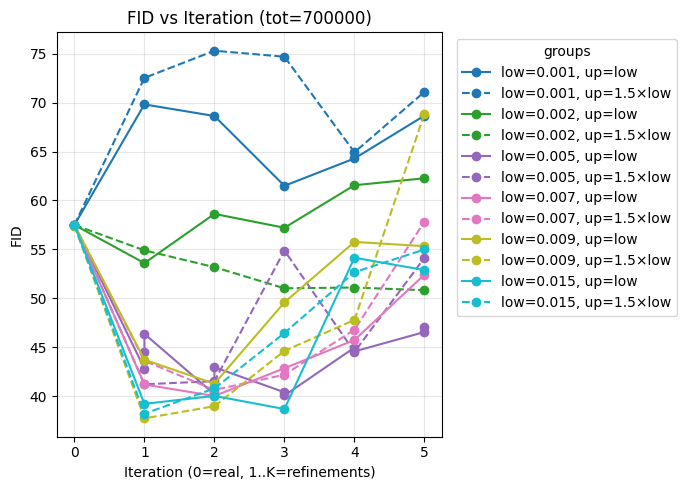

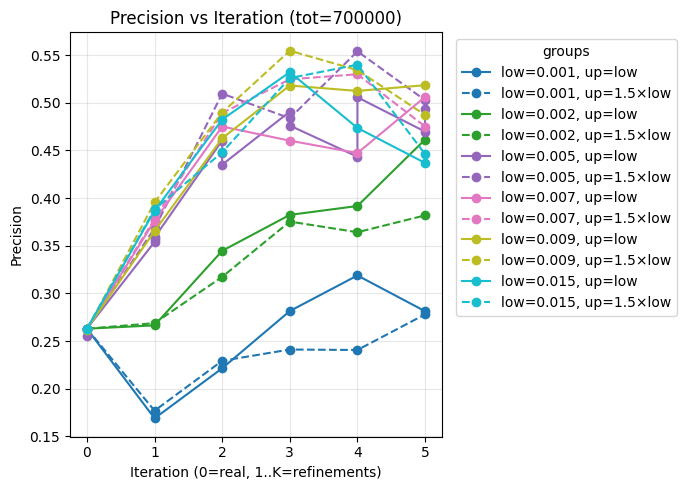

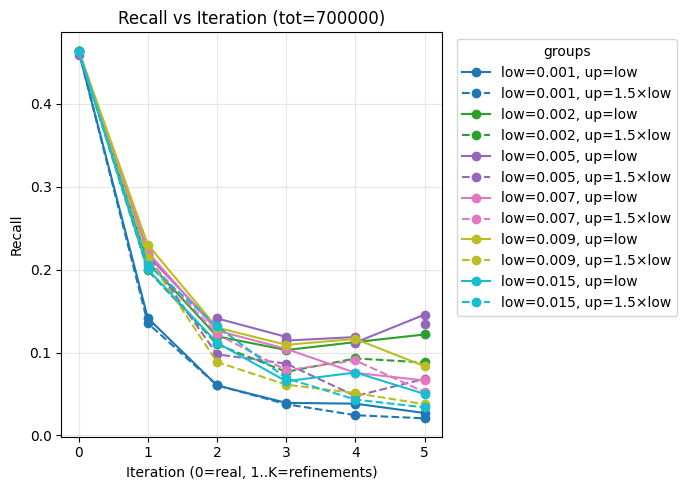

In [4]:
# Plot FID / Precision / Recall vs iteration
# - Solid line: upper = lower -> diverse_up{p}_low{p}_keep0.5_tot{TOT}
# - Dashed line: upper = 1.5*lower -> diverse_up{1.5*p}_low{p}_up1p5x_low_keep0_tot{TOT}

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# Locate MNIST root even if running from a subfolder
cwd = Path.cwd().resolve()
MNIST_ROOT = next((p for p in [cwd, *cwd.parents] if p.name == "MNIST"), None)
if MNIST_ROOT is None:
    MNIST_ROOT = Path.home() / "data_filter/Verified-Synthetic-Data/MNIST"

# Config
P_LIST = [0.001, 0.002, 0.005, 0.007, 0.009, 0.015] # 0.01, 0.015, 0.02, 0.03, 0.04]  # lower%
TOT = 700000  # set to 7000000 if your runs used that
CSV_REL = "metrics/metrics.csv"
EPS = 1e-12

def tag_to_iter(tag: str):
    if isinstance(tag, str) and tag.startswith("model_00_real"):
        return 0
    m = re.search(r"model_(\d+)", str(tag))
    return int(m.group(1)) if m else None

rows = []
for p in P_LIST:
    # equal: upper=lower=p
    d_equal = MNIST_ROOT / f"diverse_up{p:g}_low{p:g}_keep0.5_tot{TOT}"
    # 1.5x: upper=1.5*lower, keep=0, with marker 'up1p5x_low'
    up15 = 1.5 * p
    d_15x = MNIST_ROOT / f"diverse_up{up15:g}_low{p:g}_up1p5x_low_keep0_tot{TOT}"

    for kind, d in [("equal", d_equal), ("1p5x", d_15x)]:
        csv_path = d / CSV_REL
        if not csv_path.is_file():
            print(f"[SKIP] {csv_path} not found")
            continue
        df = pd.read_csv(csv_path)
        if "tag" in df.columns:
            df["iteration"] = df["tag"].apply(tag_to_iter)
        else:
            df = df.reset_index().rename(columns={"index": "iteration"})
        df = df.dropna(subset=["iteration"]).copy()
        df["iteration"] = df["iteration"].astype(int)
        df["lower_percent"] = float(p)
        df["upper_percent"] = float(p if kind == "equal" else up15)
        df["kind"] = kind  # equal or 1p5x
        rows.append(df[["iteration","fid","precision","recall","lower_percent","upper_percent","kind"]])

if not rows:
    raise RuntimeError("No metrics collected. Check folder names and TOT.")

all_df = pd.concat(rows, ignore_index=True)

def plot_metric(metric, ylabel):
    plt.figure(figsize=(7,5))
    colors = plt.cm.tab10(np.linspace(0,1,len(P_LIST)))
    color_map = {p:c for p,c in zip(P_LIST, colors)}
    for p in P_LIST:
        g = all_df[np.isclose(all_df["lower_percent"], p, atol=EPS)]
        if g.empty: 
            continue
        # solid: upper=lower; dashed: upper=1.5*lower
        for kind, ls in [("equal","-"), ("1p5x","--")]:
            gg = g[g["kind"] == kind].sort_values("iteration")
            if gg.empty:
                continue
            label = f"low={p:g}, {'up=low' if kind=='equal' else 'up=1.5×low'}"
            plt.plot(gg["iteration"], gg[metric], marker="o", color=color_map[p], linestyle=ls, label=label)
    plt.xlabel("Iteration (0=real, 1..K=refinements)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Iteration (tot={TOT})")
    plt.legend(title="groups", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric("fid", "FID")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")
